In [2]:
import tensorflow as tf
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.applications import MobileNetV2, EfficientNetB0
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [3]:
IMG_SIZE = 224
BATCH_SIZE = 16

In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)


In [34]:
def crop_center(img):
    h, w = img.shape[:2]
    startx = w // 4
    starty = h // 4
    return img[starty:starty + h//2, startx:startx + w//2]

In [5]:
train_data = train_datagen.flow_from_directory(
    r"C:\Users\bhumi\Downloads\Hybrid dataset",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_data = train_datagen.flow_from_directory(
    r"C:\Users\bhumi\Downloads\Hybrid dataset",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False   # 🔥 VERY IMPORTANT
)

Found 14710 images belonging to 4 classes.
Found 3675 images belonging to 4 classes.


In [6]:
ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

In [7]:
base1 = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)

base2 = EfficientNetB0(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)

In [8]:
for layer in base1.layers:
    layer.trainable = False

for layer in base2.layers:
    layer.trainable = False

In [9]:
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense, Dropout, Concatenate

input_layer = Input(shape=(IMG_SIZE, IMG_SIZE, 3))

# Pass same input to both models
x1 = base1(input_layer)
x1 = GlobalAveragePooling2D()(x1)

x2 = base2(input_layer)
x2 = GlobalAveragePooling2D()(x2)

# Combine features
combined = Concatenate()([x1, x2])

In [10]:
x = Dense(256, activation='relu')(combined)
x = Dropout(0.5)(x)
output = Dense(4, activation='softmax')(x)

model = Model(inputs=input_layer, outputs=output)

In [12]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [13]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=2
)

In [14]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.00001),  # slower learning
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [15]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=2
)

In [14]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=9,   
    callbacks=[early_stop, reduce_lr],

)

Epoch 1/9
920/920 ━━━━━━━━━━━━━━━━━━━━ 1420s 2s/step - accuracy: 0.7167 - loss: 0.7662 - val_accuracy: 0.8133 - val_loss: 0.5171 - learning_rate: 1.0000e-05
Epoch 2/9
920/920 ━━━━━━━━━━━━━━━━━━━━ 1384s 1s/step - accuracy: 0.8139 - loss: 0.4892 - val_accuracy: 0.8756 - val_loss: 0.3903 - learning_rate: 1.0000e-05
Epoch 3/9
920/920 ━━━━━━━━━━━━━━━━━━━━ 1464s 2s/step - accuracy: 0.8600 - loss: 0.3796 - val_accuracy: 0.9124 - val_loss: 0.3180 - learning_rate: 1.0000e-05
Epoch 4/9
920/920 ━━━━━━━━━━━━━━━━━━━━ 1372s 1s/step - accuracy: 0.8870 - loss: 0.3203 - val_accuracy: 0.9268 - val_loss: 0.2744 - learning_rate: 1.0000e-05
Epoch 5/9
920/920 ━━━━━━━━━━━━━━━━━━━━ 1313s 1s/step - accuracy: 0.9039 - loss: 0.2757 - val_accuracy: 0.9358 - val_loss: 0.2487 - learning_rate: 1.0000e-05
Epoch 6/9
920/920 ━━━━━━━━━━━━━━━━━━━━ 1261s 1s/step - accuracy: 0.9164 - loss: 0.2466 - val_accuracy: 0.9429 - val_loss: 0.2215 - learning_rate: 1.0000e-05
Epoch 7/9
920/920 ━━━━━━━━━━━━━━━━━━━━ 1315s 1s/step - acc

In [16]:
model.save("hybrid_model_final.h5")

In [18]:
model.save("final_hybrid_model.keras") 

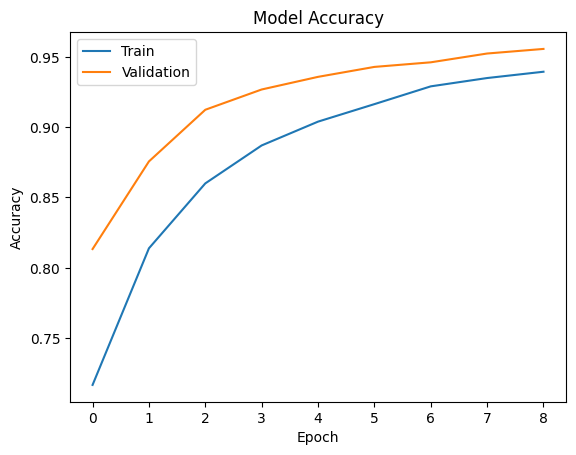

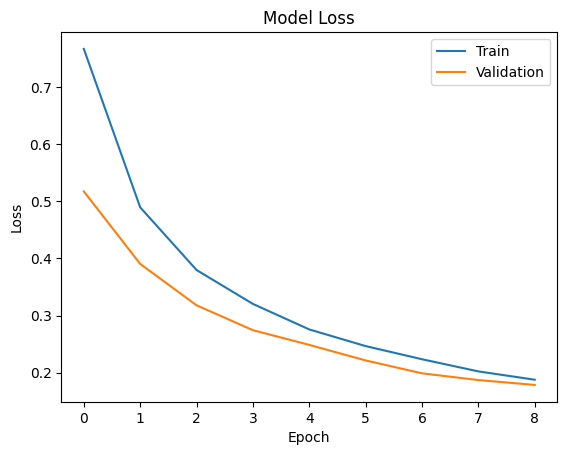

In [19]:
#graph
import matplotlib.pyplot as plt

# Accuracy Graph
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

# Loss Graph
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

In [24]:
val_data.reset()

In [25]:
y_pred = model.predict(val_data)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = val_data.classes

230/230 ━━━━━━━━━━━━━━━━━━━━ 314s 1s/step 


In [26]:
print(classification_report(y_true, y_pred_classes))

              precision    recall  f1-score   support

           0       0.94      0.96      0.95       732
           1       0.97      0.97      0.97      2504
           2       0.86      0.92      0.89        91
           3       0.90      0.86      0.88       348

    accuracy                           0.96      3675
   macro avg       0.92      0.93      0.92      3675
weighted avg       0.96      0.96      0.96      3675



In [4]:


import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from PIL import Image

# 🔥 LOAD MODEL (IMPORTANT)
model = load_model("hybrid_model_final.h5")

IMG_SIZE = (224, 224)
CLASS_NAMES = ["No DR", "Mild", "Moderate", "Severe"]

import numpy as np
from tensorflow.keras.models import load_model
from PIL import Image

# LIME
from lime import lime_image
from skimage.segmentation import mark_boundaries

# =========================
# 1. Load Model
# =========================
model = load_model("hybrid_model_final.h5")

# =========================
# 2. Config
# =========================
IMG_SIZE = (224, 224)   # NOTE: training size ke hisaab se change karo (e.g., 128x128)

CLASS_NAMES = ["No DR", "Mild", "Moderate", "Severe", "Proliferative"]

# =========================
# 3. Preprocess
# =========================
def preprocess_image(img):
    img = img.resize(IMG_SIZE)
    img = np.array(img)

    # RGBA -> RGB
    if img.shape[-1] == 4:
        img = img[:, :, :3]

    img = img.astype("float32") / 255.0
    return img

# =========================
# 4. Predict fn (for LIME)
# =========================
def predict_fn(images):
    images = np.array(images).astype("float32")

    # LIME passes uint8 [0..255], convert to [0..1]
    if images.max() > 1.0:
        images = images / 255.0

    if len(images.shape) == 3:
        images = np.expand_dims(images, axis=0)

    preds = model.predict(images, verbose=0)
    return preds

# =========================
# 5. Single prediction
# =========================
def predict_single(img):
    x = preprocess_image(img)
    x = np.expand_dims(x, axis=0)

    preds = model.predict(x, verbose=0)
    class_id = int(np.argmax(preds))

    return CLASS_NAMES[class_id], preds[0]

# =========================
# 6. LIME Explanation
# =========================
def generate_lime_explanation(img, num_samples=200, num_features=5):
    """
    Returns:
        pred_class (str),
        probs (np.array),
        overlay_img (np.array float [0..1])
    """
    # preprocess for model
    proc = preprocess_image(img)

    # LIME expects uint8 image
    lime_img = (proc * 255).astype(np.uint8)

    explainer = lime_image.LimeImageExplainer()

    explanation = explainer.explain_instance(
        image=lime_img,
        classifier_fn=predict_fn,
        top_labels=1,
        hide_color=0,
        num_samples=num_samples
    )

    label = explanation.top_labels[0]

    temp, mask = explanation.get_image_and_mask(
        label,
        positive_only=True,
        num_features=num_features,
        hide_rest=False
    )

    # boundary overlay
    overlay = mark_boundaries(temp / 255.0, mask)

    pred_class, probs = predict_single(img)

    return pred_class, probs, overlay

  0%|          | 0/1000 [00:00<?, ?it/s]

Prediction: Mild
Probabilities: [0.0013235  0.9695098  0.00372192 0.02544482]


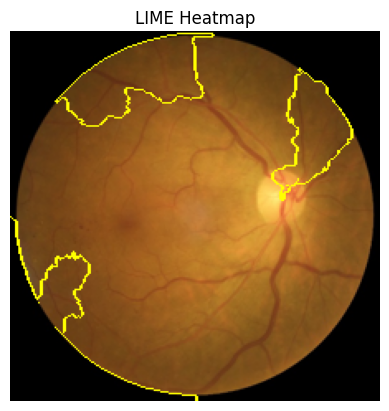

In [11]:
if __name__ == "__main__":
    from PIL import Image
    import matplotlib.pyplot as plt

    img = Image.open("sample eye img.jpg")

    pred_class, probs, lime_img = generate_lime_explanation(img)

    print("Prediction:", pred_class)
    print("Probabilities:", probs)

    plt.imshow(lime_img)
    plt.axis('off')
    plt.title("LIME Heatmap")
    plt.show()